# KYC Risk Scorer — End-to-End SageMaker Walkthrough

This notebook runs the full ML pipeline **step by step on AWS SageMaker** so you can observe real
logs and outputs at every stage before automating it via `pipeline.py`.

| Step | What runs | Where |
|------|-----------|-------|
| 1 | Load real KYC dataset, fix column names, upload to S3 | Local |
| 2 | **Preprocess** — encode ordinals, 80/20 stratified split | SageMaker Processing (SKLearn) |
| 3 | **Train** — XGBoost `multi:softprob`, 3 risk classes | SageMaker Training (XGBoost) |
| 4 | **Evaluate** — AUC, accuracy, per-class F1, confusion matrix | SageMaker Processing (SKLearn) |
| 5 | **Quality gate** — AUC ≥ threshold check | Local |
| 6 | **Register** — push to SageMaker Model Registry | SageMaker |
| 7 | **Deploy** — real-time endpoint + smoke test | SageMaker |
| 8 | **Cleanup** — delete endpoint to stop charges | SageMaker |

**Prerequisites:**
```
pip install sagemaker boto3 xgboost pandas scikit-learn matplotlib seaborn openpyxl
```
You also need a SageMaker execution role ARN and an S3 bucket — fill both in the **Configuration** cell below.

In [1]:
!pip install sagemaker boto3 xgboost pandas scikit-learn matplotlib seaborn openpyxl

In [1]:
import sys
print(sys.executable)
import sagemaker
print(sagemaker.__file__)
print(sagemaker.__version__)

/opt/conda/bin/python


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py
2.257.3


In [2]:
import sys, sagemaker
print("file:", sagemaker.__file__)
print("path:", list(sagemaker.__path__))
print()
print("sys.path entries:")
for p in sys.path:
    print(" ", p)

file: /opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py
path: ['/opt/conda/lib/python3.12/site-packages/sagemaker']

sys.path entries:
  /opt/conda/lib/python312.zip
  /opt/conda/lib/python3.12
  /opt/conda/lib/python3.12/lib-dynload
  
  /opt/conda/lib/python3.12/site-packages


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import io
import json
import os
import tarfile
import time

# ── Third-party ───────────────────────────────────────────────────────────────
import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sagemaker
import xgboost as xgb
from IPython.display import display

# Quick version check so you know what you're running
print(f'sagemaker : {sagemaker.__version__}')
print(f'boto3     : {boto3.__version__}')
print(f'xgboost   : {xgb.__version__}')
print(f'pandas    : {pd.__version__}')
print(f'numpy     : {np.__version__}')

sagemaker : 2.257.3
boto3     : 1.43.40
xgboost   : 2.1.4
pandas    : 3.0.3
numpy     : 2.5.1


## ⚙️ 0. Configuration

**Fill in `ROLE` and `BUCKET` before running any cell below.**
Everything else has sensible defaults that match the `pipeline.py` settings.

In [3]:
# ── Required: update these two ────────────────────────────────────────────────
ROLE   = 'arn:aws:iam::926529379586:role/kyc-agent-roles-sagemaker-execution-role'
BUCKET = 'kyc-agent-mlops-926529379586-us-east-1'               # your S3 bucket (must already exist)

# ── Optional overrides ────────────────────────────────────────────────────────
REGION          = 'us-east-1'      # AWS region
AUC_THRESHOLD   = 0.85             # quality gate: model must beat this to register
ENDPOINT_NAME   = 'kyc-risk-scorer'
INSTANCE_PROC   = 'ml.m5.large'    # processing jobs (preprocess + evaluate)
INSTANCE_TRAIN  = 'ml.m5.xlarge'   # training job
INSTANCE_INFER  = 'ml.m5.large'    # real-time endpoint

# S3 URI prefixes (all artefacts land under the same bucket)
S3_RAW        = f's3://{BUCKET}/kyc-risk-raw/training'
S3_PROCESSED  = f's3://{BUCKET}/kyc-risk-processed'
S3_MODEL      = f's3://{BUCKET}/kyc-risk-model'
S3_EVALUATION = f's3://{BUCKET}/kyc-risk-evaluation'

# AWS SDK clients
boto_sess  = boto3.Session(region_name=REGION)
session    = sagemaker.Session(boto_session=boto_sess, default_bucket=BUCKET)
s3_client  = boto3.client('s3',         region_name=REGION)
sm_client  = boto3.client('sagemaker',  region_name=REGION)
rt_client  = boto3.client('sagemaker-runtime', region_name=REGION)

print(f'Role    : {ROLE}')
print(f'Bucket  : {BUCKET}')
print(f'Region  : {REGION}')

Role    : arn:aws:iam::926529379586:role/kyc-agent-roles-sagemaker-execution-role
Bucket  : kyc-agent-mlops-926529379586-us-east-1
Region  : us-east-1


## 📂 Step 1: Load Dataset & Upload to S3

We use the real KYC cases from `dataset/kyc_train.csv` and `dataset/kyc_test.csv`.

**Column name mismatch to fix before uploading:**

| Dataset column | `preprocess.py` expects |
|----------------|-------------------------|
| `doc_verification_status` | `doc_status` |
| `adverse_media_hit_count` | `adverse_media_hits` |

We merge both splits into one file and upload it — `preprocess.py` will do its own 80/20 stratified re-split on SageMaker.

In [4]:
# Path is relative to this notebook; scripts/ and dataset/ live alongside it
DATASET_DIR = ''

df_train_raw = pd.read_csv(os.path.join(DATASET_DIR, 'kyc_train.csv'))
df_test_raw  = pd.read_csv(os.path.join(DATASET_DIR, 'kyc_test.csv'))

print(f'Train file : {len(df_train_raw)} rows')
print(f'Test file  : {len(df_test_raw)} rows')

# ── Rename to match preprocess.py's expected column names ─────────────────────
RENAME = {
    'doc_verification_status': 'doc_status',
    'adverse_media_hit_count' : 'adverse_media_hits',
}
df_train_raw = df_train_raw.rename(columns=RENAME)
df_test_raw  = df_test_raw.rename(columns=RENAME)

# ── Merge into one CSV (preprocess.py re-splits on SageMaker) ─────────────────
df_combined = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
print(f'\nCombined   : {len(df_combined)} rows')
print(f'Columns    : {list(df_combined.columns)}')

# ── Label distribution ────────────────────────────────────────────────────────
print('\nLabel distribution:')
vc = df_combined['final_risk_label'].value_counts()
for label, count in vc.items():
    bar = '█' * count
    print(f'  {label:<8}: {count:>3}  {bar}')

# ── Preview raw data ──────────────────────────────────────────────────────────
print('\nSample rows (raw, before encoding):')
display(df_combined.head(8))

Train file : 120 rows
Test file  : 30 rows

Combined   : 150 rows
Columns    : ['pep_match_score', 'pep_match_type', 'sanctions_hit', 'doc_status', 'doc_authenticity_score', 'adverse_media_hits', 'adverse_media_severity', 'country_risk_tier', 'final_risk_label']

Label distribution:
  low     :  90  ██████████████████████████████████████████████████████████████████████████████████████████
  medium  :  37  █████████████████████████████████████
  high    :  23  ███████████████████████

Sample rows (raw, before encoding):


,pep_match_score,pep_match_type,sanctions_hit,doc_status,doc_authenticity_score,adverse_media_hits,adverse_media_severity,country_risk_tier,final_risk_label
0,57,fuzzy,1,verified,83,4,4,high,high
1,17,none,0,verified,81,0,0,low,low
2,17,none,0,unreadable,50,0,0,medium,medium
3,1,none,0,verified,97,0,0,low,low
4,18,none,0,failed,4,1,4,medium,medium
5,10,none,0,verified,91,2,1,low,low
6,5,none,0,verified,90,0,0,low,low
7,4,none,0,verified,91,2,3,low,medium


In [5]:
# ── Upload combined CSV to S3 ─────────────────────────────────────────────────
buf = io.StringIO()
df_combined.to_csv(buf, index=False)

s3_key        = 'kyc-risk-raw/training/kyc_combined.csv'
input_s3_uri  = f's3://{BUCKET}/{s3_key}'

s3_client.put_object(
    Bucket=BUCKET,
    Key=s3_key,
    Body=buf.getvalue().encode('utf-8'),
)

print(f'Uploaded {len(df_combined)} rows')
print(f'S3 URI : {input_s3_uri}')

Uploaded 150 rows
S3 URI : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-raw/training/kyc_combined.csv


---
### 🔬 2a. Inside `preprocess.py` — Local Step-by-Step Walkthrough

Before submitting the SageMaker job, the cells below run the **exact same logic** as `preprocess.py` locally on `df_combined` so you can see what happens to the data at every sub-step.

`preprocess.py` does four things in order:

| Sub-step | What happens |
|----------|-------------|
| 1 | **Ordinal-encode** categorical string columns (`pep_match_type`, `doc_status`, `adverse_media_severity`, `country_risk_tier`) → integers |
| 2 | **Clip** continuous numeric features to expected bounds (guards against outliers) |
| 3 | **Encode** the target label (`final_risk_label` → 0/1/2) and drop unknowns |
| 4 | **Stratified 80/20 split** → write two headerless CSVs with label as column 0 (XGBoost convention) |

In [7]:
# ── Encoding maps (from preprocess.py) ────────────────────────────────────────
# These dictionaries convert string categorical values to ordered integers.
# The ordering is meaningful: higher number = higher risk for ordinal features
# (e.g., verified > unreadable > failed for doc_status).

PEP_MATCH_TYPE_MAP  = {"none": 0, "fuzzy": 1, "exact": 2}
DOC_STATUS_MAP      = {"failed": 0, "unreadable": 1, "verified": 2}
ADVERSE_SEV_MAP     = {"none": 0, "low": 1, "medium": 2, "high": 3, "critical": 4}
COUNTRY_RISK_MAP    = {"low": 1, "medium": 2, "high": 3, "very_high": 4, "critical": 5}
LABEL_MAP_ENC       = {"low": 0, "medium": 1, "high": 2, "rejected": 2}

# Reverse map used for display only (numeric label → human-readable string)
LABEL_DECODE = {0: "low", 1: "medium", 2: "high"}

print("Encoding maps:")
print(f"  pep_match_type   : {PEP_MATCH_TYPE_MAP}")
print(f"  doc_status       : {DOC_STATUS_MAP}")
print(f"  adverse_sev      : {ADVERSE_SEV_MAP}")
print(f"  country_risk     : {COUNTRY_RISK_MAP}")
print(f"  final_risk_label : {LABEL_MAP_ENC}  (rejected → same bucket as high)")
print()
print("Raw categorical values in df_combined (before encoding):")
display(df_combined[['pep_match_type', 'doc_status', 'adverse_media_severity',
                      'country_risk_tier', 'final_risk_label']].head(8))

Encoding maps:
  pep_match_type   : {'none': 0, 'fuzzy': 1, 'exact': 2}
  doc_status       : {'failed': 0, 'unreadable': 1, 'verified': 2}
  adverse_sev      : {'none': 0, 'low': 1, 'medium': 2, 'high': 3, 'critical': 4}
  country_risk     : {'low': 1, 'medium': 2, 'high': 3, 'very_high': 4, 'critical': 5}
  final_risk_label : {'low': 0, 'medium': 1, 'high': 2, 'rejected': 2}  (rejected → same bucket as high)

Raw categorical values in df_combined (before encoding):


,pep_match_type,doc_status,adverse_media_severity,country_risk_tier,final_risk_label
0,fuzzy,verified,4,high,high
1,none,verified,0,low,low
2,none,unreadable,0,medium,medium
3,none,verified,0,low,low
4,none,failed,4,medium,medium
5,none,verified,1,low,low
6,none,verified,0,low,low
7,none,verified,3,low,medium


In [8]:
# ── Apply ordinal encoding to each categorical column ─────────────────────────
# The helper mirrors _encode_ordinal() in preprocess.py.
# It handles two cases: string columns (map via dict) and already-numeric columns
# (pass through unchanged — some datasets use integers directly).

def _encode_ordinal(series: pd.Series, mapping: dict, default: int) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series.fillna(default).astype(int)
    return series.str.lower().map(mapping).fillna(default).astype(int)

# Work on a copy so df_combined stays intact for reference
df_enc = df_combined.copy()

df_enc['pep_match_type'] = _encode_ordinal(df_enc['pep_match_type'], PEP_MATCH_TYPE_MAP, 0)
print("pep_match_type   (none→0, fuzzy→1, exact→2):")
print(" ", df_enc['pep_match_type'].value_counts().sort_index().to_dict())

df_enc['doc_status'] = _encode_ordinal(df_enc['doc_status'], DOC_STATUS_MAP, 0)
print("\ndoc_status   (failed→0, unreadable→1, verified→2):")
print(" ", df_enc['doc_status'].value_counts().sort_index().to_dict())

df_enc['adverse_media_severity'] = _encode_ordinal(df_enc['adverse_media_severity'], ADVERSE_SEV_MAP, 0)
print("\nadverse_media_severity   (none→0 … critical→4):")
print(" ", df_enc['adverse_media_severity'].value_counts().sort_index().to_dict())

df_enc['country_risk_tier'] = _encode_ordinal(df_enc['country_risk_tier'], COUNTRY_RISK_MAP, 2)
print("\ncountry_risk_tier   (low→1 … critical→5):")
print(" ", df_enc['country_risk_tier'].value_counts().sort_index().to_dict())

print()
print("Encoded categorical columns — first 5 rows:")
display(df_enc[['pep_match_type', 'doc_status', 'adverse_media_severity', 'country_risk_tier']].head(5))

pep_match_type   (none→0, fuzzy→1, exact→2):
  {0: 112, 1: 26, 2: 12}

doc_status   (failed→0, unreadable→1, verified→2):
  {0: 12, 1: 14, 2: 124}

adverse_media_severity   (none→0 … critical→4):
  {0: 90, 1: 14, 2: 18, 3: 11, 4: 11, 5: 6}

country_risk_tier   (low→1 … critical→5):
  {1: 109, 2: 21, 3: 20}

Encoded categorical columns — first 5 rows:


,pep_match_type,doc_status,adverse_media_severity,country_risk_tier
0,1,2,4,3
1,0,2,0,1
2,0,1,0,2
3,0,2,0,1
4,0,0,4,2


In [9]:
# ── Clip numeric features ─────────────────────────────────────────────────────
# Clipping guards against impossible outlier values (e.g., a pep_match_score > 100
# would be a data entry error). It also constrains the feature range to what
# the model was trained on, preventing unexpected behaviour at inference time.

print("Before clipping — min/max of numeric features:")
for col, lo, hi in [
    ('pep_match_score',        0, 100),
    ('doc_authenticity_score', 0, 100),
    ('adverse_media_hits',     0,  50),
]:
    print(f"  {col:<28}  min={df_enc[col].min():.0f}  max={df_enc[col].max():.0f}  "
          f"→ clip to [{lo}, {hi}]")

df_enc['pep_match_score']        = df_enc['pep_match_score'].clip(0, 100).fillna(0)
df_enc['doc_authenticity_score'] = df_enc['doc_authenticity_score'].clip(0, 100).fillna(0)
df_enc['adverse_media_hits']     = df_enc['adverse_media_hits'].clip(0, 50).fillna(0)
df_enc['sanctions_hit']          = df_enc['sanctions_hit'].fillna(0).astype(int)

print()
print("After clipping — describe() for the affected columns:")
display(df_enc[['pep_match_score', 'doc_authenticity_score',
                'adverse_media_hits', 'sanctions_hit']].describe().round(2))

Before clipping — min/max of numeric features:
  pep_match_score               min=0  max=88  → clip to [0, 100]
  doc_authenticity_score        min=0  max=99  → clip to [0, 100]
  adverse_media_hits            min=0  max=5  → clip to [0, 50]

After clipping — describe() for the affected columns:


,pep_match_score,doc_authenticity_score,adverse_media_hits,sanctions_hit
count,150.00,150.00,150.00,150.00
mean,22.74,80.27,0.75,0.11
std,25.08,23.69,1.18,0.32
min,0.00,0.00,0.00,0.00
25%,5.00,81.00,0.00,0.00
50%,13.00,87.50,0.00,0.00
75%,33.25,94.75,1.00,0.00
max,88.00,99.00,5.00,1.00


In [10]:
# ── Encode the target label ───────────────────────────────────────────────────
# 'rejected' maps to the same integer as 'high' (both → 2) because a rejected
# case represents the highest risk level in the KYC workflow.
# Rows with an unrecognised label value are dropped to avoid corrupt training data.

print("Label values before encoding:")
print(df_enc['final_risk_label'].value_counts().to_dict())
print()

df_enc['final_risk_label'] = df_enc['final_risk_label'].str.lower().map(LABEL_MAP_ENC)
df_enc = df_enc.dropna(subset=['final_risk_label'])   # drop rows with unknown label strings
df_enc['final_risk_label'] = df_enc['final_risk_label'].astype(int)

print("Label distribution after encoding  (low=0, medium=1, high=2):")
vc = df_enc['final_risk_label'].value_counts().sort_index()
for code, count in vc.items():
    bar = '█' * count
    print(f"  {code} ({LABEL_DECODE[code]:<8}): {count:>3}  {bar}")

print()
print("All features are now numeric. Sample of the fully-encoded DataFrame:")
display(df_enc.head(5))

Label values before encoding:
{'low': 90, 'medium': 37, 'high': 23}

Label distribution after encoding  (low=0, medium=1, high=2):
  0 (low     ):  90  ██████████████████████████████████████████████████████████████████████████████████████████
  1 (medium  ):  37  █████████████████████████████████████
  2 (high    ):  23  ███████████████████████

All features are now numeric. Sample of the fully-encoded DataFrame:


,pep_match_score,pep_match_type,sanctions_hit,doc_status,doc_authenticity_score,adverse_media_hits,adverse_media_severity,country_risk_tier,final_risk_label
0,57,1,1,2,83,4,4,3,2
1,17,0,0,2,81,0,0,1,0
2,17,0,0,1,50,0,0,2,1
3,1,0,0,2,97,0,0,1,0
4,18,0,0,0,4,1,4,2,1


In [11]:
# ── Stratified 80/20 train/test split ─────────────────────────────────────────
# 'stratify=y' ensures each risk class appears in the same proportion in both
# splits. Without it, a random split could send all 'high' cases to train only.

from sklearn.model_selection import train_test_split

FEATURE_ORDER_ENC = [
    'pep_match_score', 'sanctions_hit', 'doc_authenticity_score',
    'adverse_media_hits', 'adverse_media_severity',
    'pep_match_type', 'doc_status', 'country_risk_tier',
]
LABEL_COL_ENC = 'final_risk_label'

X = df_enc[FEATURE_ORDER_ENC]
y = df_enc[LABEL_COL_ENC]

X_train_loc, X_test_loc, y_train_loc, y_test_loc = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total rows : {len(df_enc)}")
print(f"Train      : {len(X_train_loc)} rows (80%)")
print(f"Test       : {len(X_test_loc)} rows (20%)")
print()
print("Class proportions — verify stratification kept them consistent:")
print(f"  {'Class':<8}  {'Full':>6}  {'Train':>6}  {'Test':>6}")
print("  " + "─" * 32)
for code in sorted(y.unique()):
    name    = LABEL_DECODE[code]
    p_full  = (y == code).mean()
    p_train = (y_train_loc == code).mean()
    p_test  = (y_test_loc == code).mean()
    print(f"  {name:<8}  {p_full:>6.1%}  {p_train:>6.1%}  {p_test:>6.1%}")

Total rows : 150
Train      : 120 rows (80%)
Test       : 30 rows (20%)

Class proportions — verify stratification kept them consistent:
  Class       Full   Train    Test
  ────────────────────────────────
  low        60.0%   60.0%   60.0%
  medium     24.7%   25.0%   23.3%
  high       15.3%   15.0%   16.7%


In [12]:
# ── Assemble the final output CSVs ────────────────────────────────────────────
# XGBoost's built-in CSV data loader expects: col-0 = label, no header row.
# Putting the label first removes the need to specify a label column at load time.

train_out_local = pd.concat(
    [y_train_loc.reset_index(drop=True), X_train_loc.reset_index(drop=True)], axis=1
)
test_out_local = pd.concat(
    [y_test_loc.reset_index(drop=True), X_test_loc.reset_index(drop=True)], axis=1
)

print("Final output format — train.csv (label first, no header):")
print(f"Shape  : {train_out_local.shape}")
print(f"Columns: {list(train_out_local.columns)}")
print()
display(train_out_local.head(5))

print(f"\nFinal output format — test.csv:")
print(f"Shape  : {test_out_local.shape}")
display(test_out_local.head(5))

print("\npreprocess.py writes these to /opt/ml/processing/output/train and /test")
print("SageMaker then uploads them to:")
print(f"  {S3_PROCESSED}/train/train.csv")
print(f"  {S3_PROCESSED}/test/test.csv")

Final output format — train.csv (label first, no header):
Shape  : (120, 9)
Columns: ['final_risk_label', 'pep_match_score', 'sanctions_hit', 'doc_authenticity_score', 'adverse_media_hits', 'adverse_media_severity', 'pep_match_type', 'doc_status', 'country_risk_tier']



,final_risk_label,pep_match_score,sanctions_hit,doc_authenticity_score,adverse_media_hits,adverse_media_severity,pep_match_type,doc_status,country_risk_tier
0,0,16,0,80,0,0,0,2,1
1,2,81,1,54,2,4,2,1,3
2,0,13,0,89,0,0,0,2,1
3,0,14,0,89,0,0,0,2,1
4,0,12,0,87,0,0,0,2,1



Final output format — test.csv:
Shape  : (30, 9)


,final_risk_label,pep_match_score,sanctions_hit,doc_authenticity_score,adverse_media_hits,adverse_media_severity,pep_match_type,doc_status,country_risk_tier
0,0,11,0,96,0,0,0,2,1
1,1,6,0,99,0,0,0,2,2
2,0,6,0,88,0,0,0,2,1
3,0,1,0,60,0,0,0,1,1
4,0,1,0,89,0,0,0,2,1



preprocess.py writes these to /opt/ml/processing/output/train and /test
SageMaker then uploads them to:
  s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-processed/train/train.csv
  s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-processed/test/test.csv


## 🔄 Step 2: Preprocess on SageMaker

`SKLearnProcessor` runs `scripts/preprocess.py` in a managed container on `ml.m5.large`.

**Encoding applied by the script:**

| Feature | Encoding |
|---------|----------|
| `pep_match_type` | none→0, fuzzy→1, exact→2 |
| `doc_status` | failed→0, unreadable→1, verified→2 |
| `adverse_media_severity` | none→0, low→1, medium→2, high→3, critical→4 |
| `country_risk_tier` | low→1, medium→2, high→3, very_high→4, critical→5 |
| `final_risk_label` | low→0, medium→1, high/rejected→2 |
| `pep_match_score` | clipped to [0, 100] |
| `doc_authenticity_score` | clipped to [0, 100] |
| `adverse_media_hits` | clipped to [0, 50] |

**Output:** two headerless CSVs with **label as column 0** (XGBoost convention) — `train.csv` (80%) and `test.csv` (20%).

Job logs stream inline below. Typical runtime: **3–5 minutes** on first run (container pull + job).

In [6]:
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.processing import ProcessingInput, ProcessingOutput

sklearn_proc = SKLearnProcessor(
    framework_version='1.2-1',
    instance_type=INSTANCE_PROC,
    instance_count=1,
    role=ROLE,
    sagemaker_session=session,
    base_job_name='kyc-preprocess',
)

print('Submitting preprocessing job …')
print(f'  Input  : {input_s3_uri}')
print(f'  Output : {S3_PROCESSED}/train  and  {S3_PROCESSED}/test')
print()

sklearn_proc.run(
    # Path is relative to the notebook's working directory (sagemaker/)
    code='scripts/preprocess.py',
    inputs=[
        ProcessingInput(
            source=input_s3_uri,
            destination='/opt/ml/processing/input',
        )
    ],
    outputs=[
        ProcessingOutput(
            output_name='train',
            source='/opt/ml/processing/output/train',
            destination=f'{S3_PROCESSED}/train',
        ),
        ProcessingOutput(
            output_name='test',
            source='/opt/ml/processing/output/test',
            destination=f'{S3_PROCESSED}/test',
        ),
    ],
    arguments=['--test-size', '0.2', '--random-seed', '42'],
    wait=True,   # block until job finishes, streaming logs inline
    logs=True,
)

preprocess_job_name = sklearn_proc.latest_job.job_name
print(f'\n✓ Preprocessing complete')
print(f'  Job name : {preprocess_job_name}')

INFO:sagemaker:Creating processing-job with name kyc-preprocess-2026-07-08-22-10-26-061


Submitting preprocessing job …
  Input  : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-raw/training/kyc_combined.csv
  Output : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-processed/train  and  s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-processed/test



.

.

.

...

.

.

.

Loaded 150 rows | columns: ['pep_match_score', 'pep_match_type', 'sanctions_hit', 'doc_status', 'doc_authenticity_score', 'adverse_media_hits', 'adverse_media_severity', 'country_risk_tier', 'final_risk_label']
After encoding: 150 rows | label distribution:
{0: 90, 1: 37, 2: 23}
Wrote 120 train rows → /opt/ml/processing/output/train/train.csv
Wrote 30 test rows  → /opt/ml/processing/output/test/test.csv



✓ Preprocessing complete
  Job name : kyc-preprocess-2026-07-08-22-10-26-061


In [7]:
# ── Download the preprocessed splits from S3 and inspect them ─────────────────
#
# preprocess.py writes headerless CSVs with label in column 0 — that is the
# XGBoost built-in CSV loader convention. We add column names here for display.

FEATURE_NAMES = [
    'pep_match_score', 'sanctions_hit', 'doc_authenticity_score',
    'adverse_media_hits', 'adverse_media_severity',
    'pep_match_type', 'doc_status', 'country_risk_tier',
]
LABEL_DECODE = {0: 'low', 1: 'medium', 2: 'high'}


def download_processed_split(s3_prefix: str, filename: str) -> pd.DataFrame:
    """Download a processed CSV from S3 and attach column headers."""
    key = s3_prefix.replace(f's3://{BUCKET}/', '') + f'/{filename}'
    obj = s3_client.get_object(Bucket=BUCKET, Key=key)
    df  = pd.read_csv(io.BytesIO(obj['Body'].read()), header=None)
    df.columns = ['label'] + FEATURE_NAMES
    return df


df_proc_train = download_processed_split(f'{S3_PROCESSED}/train', 'train.csv')
df_proc_test  = download_processed_split(f'{S3_PROCESSED}/test',  'test.csv')

print(f'Train split : {len(df_proc_train)} rows   |   '
      f'Test split : {len(df_proc_test)} rows')

# ── Label distribution after encoding ─────────────────────────────────────────
print('\nTrain label distribution (encoded → decoded):')
for code, count in df_proc_train['label'].value_counts().sort_index().items():
    print(f'  {code} → {LABEL_DECODE[code]:<8}: {count} rows')

# ── Feature statistics ────────────────────────────────────────────────────────
print('\nTrain feature summary (all values are now numeric):')
display(df_proc_train[FEATURE_NAMES].describe().round(2))

# ── Sample rows showing the label-first, headerless format ───────────────────
print('\nFirst 5 rows of train.csv (col-0 = label, then 8 features):')
display(df_proc_train.head(5))

Train split : 120 rows   |   Test split : 30 rows

Train label distribution (encoded → decoded):
  0 → low     : 72 rows
  1 → medium  : 30 rows
  2 → high    : 18 rows

Train feature summary (all values are now numeric):


,pep_match_score,sanctions_hit,doc_authenticity_score,adverse_media_hits,adverse_media_severity,pep_match_type,doc_status,country_risk_tier
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.0
mean,24.57,0.12,80.28,0.68,1.04,0.38,1.75,1.4
std,26.30,0.32,24.12,1.09,1.50,0.66,0.60,0.7
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0
25%,6.00,0.00,81.00,0.00,0.00,0.00,2.00,1.0
50%,14.00,0.00,87.00,0.00,0.00,0.00,2.00,1.0
75%,42.00,0.00,95.00,1.00,2.00,1.00,2.00,2.0
max,88.00,1.00,99.00,5.00,5.00,2.00,2.00,3.0



First 5 rows of train.csv (col-0 = label, then 8 features):


,label,pep_match_score,sanctions_hit,doc_authenticity_score,adverse_media_hits,adverse_media_severity,pep_match_type,doc_status,country_risk_tier
0,0,16,0,80,0,0,0,2,1
1,2,81,1,54,2,4,2,1,3
2,0,13,0,89,0,0,0,2,1
3,0,14,0,89,0,0,0,2,1
4,0,12,0,87,0,0,0,2,1


---
### 🔬 3a. Inside `train.py` — Local Training Walkthrough

`train.py` runs on SageMaker in Step 3 below. The cells here run the **exact same logic locally** so you can:

- See how XGBoost converts the preprocessed CSV into a **DMatrix**
- Understand what each hyperparameter controls
- Watch the **train vs validation loss** per boosting round
- See where early stopping triggers and why

Uses `X_train_loc` / `X_test_loc` from the preprocessing walkthrough above.

In [15]:
# ── DMatrix: XGBoost's internal data format ───────────────────────────────────
# train.py reads the headerless CSVs (col-0 = label) and builds a DMatrix.
# DMatrix is XGBoost's optimised, compressed data structure — faster and
# more memory-efficient than a raw numpy array during training.

import xgboost as xgb

dtrain_local = xgb.DMatrix(X_train_loc.values, label=y_train_loc.values)
dval_local   = xgb.DMatrix(X_test_loc.values,  label=y_test_loc.values)

print("DMatrix objects created:")
print(f"  dtrain_local : {dtrain_local.num_row()} rows × {dtrain_local.num_col()} features")
print(f"  dval_local   : {dval_local.num_row()} rows × {dval_local.num_col()} features")
print()
print("The validation DMatrix is passed to xgb.train() for early stopping only.")
print("Its labels are never used for gradient updates — no data leakage.")

DMatrix objects created:
  dtrain_local : 120 rows × 8 features
  dval_local   : 30 rows × 8 features

The validation DMatrix is passed to xgb.train() for early stopping only.
Its labels are never used for gradient updates — no data leakage.


In [16]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
# These match exactly what the SageMaker XGBoost Estimator passes as CLI args
# to train.py in Step 3.

params_local = {
    "objective"        : "multi:softprob",  # output P(low), P(medium), P(high) per row
    "num_class"        : 3,
    "max_depth"        : 5,    # max tree depth — deeper → more complex, more overfit-prone
    "eta"              : 0.1,  # learning rate — smaller → slower but often better final quality
    "subsample"        : 0.8,  # sample 80% of rows per tree (reduces overfitting)
    "colsample_bytree" : 0.8,  # sample 80% of features per tree (reduces overfitting)
    "min_child_weight" : 5,    # min sum of instance weights in a leaf (regularisation)
    "eval_metric"      : ["mlogloss", "merror"],
    "seed"             : 42,
    "verbosity"        : 0,
}

print(f"{'Parameter':<22}  {'Value':<18}  Role")
print("─" * 75)
roles = {
    "objective"        : "loss function — 3-class softmax probability",
    "num_class"        : "number of output classes (low / medium / high)",
    "max_depth"        : "max depth per tree (complexity control)",
    "eta"              : "learning rate / step-size shrinkage",
    "subsample"        : "row sampling fraction per tree (anti-overfit)",
    "colsample_bytree" : "feature sampling fraction per tree (anti-overfit)",
    "min_child_weight" : "min sum of leaf weights (regularisation)",
    "eval_metric"      : "validation metrics logged each round",
}
for k, v in params_local.items():
    role = roles.get(k, "")
    print(f"{k:<22}  {str(v):<18}  {role}")

Parameter               Value               Role
───────────────────────────────────────────────────────────────────────────
objective               multi:softprob      loss function — 3-class softmax probability
num_class               3                   number of output classes (low / medium / high)
max_depth               5                   max depth per tree (complexity control)
eta                     0.1                 learning rate / step-size shrinkage
subsample               0.8                 row sampling fraction per tree (anti-overfit)
colsample_bytree        0.8                 feature sampling fraction per tree (anti-overfit)
min_child_weight        5                   min sum of leaf weights (regularisation)
eval_metric             ['mlogloss', 'merror']  validation metrics logged each round
seed                    42                  
verbosity               0                   


In [18]:
# ── Train locally — same logic as train.py running on SageMaker ───────────────
# evals_result captures the loss at every boosting round so we can plot curves.
# verbose_eval=10 prints a summary every 10 rounds.

evals_result = {}

print("Training XGBoost locally (up to 150 rounds, early-stop if no improvement for 15)…")
print()

model_local = xgb.train(
    params_local,
    dtrain_local,
    num_boost_round=150,
    evals=[(dtrain_local, "train"), (dval_local, "validation")],
    early_stopping_rounds=15,
    evals_result=evals_result,
    verbose_eval=10,
)

# Compute train-set AUC (same log line as in train.py)
from sklearn.metrics import roc_auc_score as _roc_auc
y_train_true = dtrain_local.get_label().astype(int)
proba_train  = model_local.predict(dtrain_local).reshape(-1, 3)
auc_train    = _roc_auc(y_train_true, proba_train, multi_class='ovr', average='macro')

print(f"\nBest boosting round   : {model_local.best_iteration}")
print(f"Train AUC (macro OVR) : {auc_train:.4f}")
print()
print("On SageMaker, train.py saves the model to /opt/ml/model/xgboost-model")
print("and writes model_meta.json alongside it before SageMaker tars + uploads to S3.")

Training XGBoost locally (up to 150 rounds, early-stop if no improvement for 15)…

[0]	train-mlogloss:1.02907	train-merror:0.20833	validation-mlogloss:1.04043	validation-merror:0.23333


[10]	train-mlogloss:0.59254	train-merror:0.12500	validation-mlogloss:0.66304	validation-merror:0.16667


[19]	train-mlogloss:0.45353	train-merror:0.10833	validation-mlogloss:0.54887	validation-merror:0.13333



Best boosting round   : 5
Train AUC (macro OVR) : 0.9590

On SageMaker, train.py saves the model to /opt/ml/model/xgboost-model
and writes model_meta.json alongside it before SageMaker tars + uploads to S3.


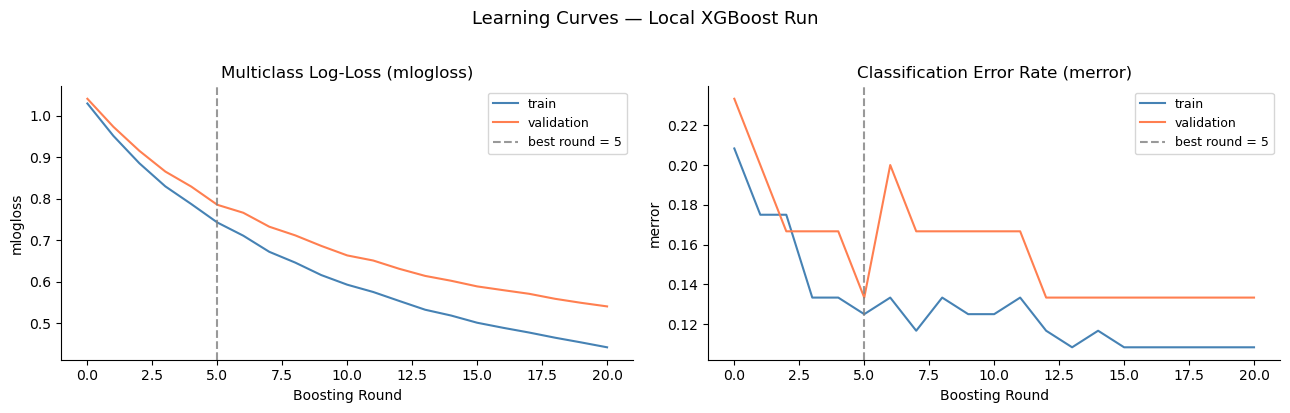

At best round 5:
  train mlogloss : 0.7424
  val   mlogloss : 0.7850
  gap            : 0.0426  (small gap = model generalises well)


In [19]:
# ── Learning curves ───────────────────────────────────────────────────────────
# mlogloss (multiclass log-loss) is the primary metric — lower is better.
# merror is the classification error rate (fraction of wrong predictions).
#
# What to look for:
#   • Both curves decreasing = model is learning
#   • Large gap between train and validation = overfitting
#   • Validation curve flattening or rising = where early stopping triggers

rounds = list(range(len(evals_result['train']['mlogloss'])))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in [
    (axes[0], 'mlogloss', 'Multiclass Log-Loss (mlogloss)'),
    (axes[1], 'merror',   'Classification Error Rate (merror)'),
]:
    ax.plot(rounds, evals_result['train'][metric],
            label='train', color='steelblue', linewidth=1.5)
    ax.plot(rounds, evals_result['validation'][metric],
            label='validation', color='coral', linewidth=1.5)
    ax.axvline(model_local.best_iteration, color='grey', linestyle='--',
               alpha=0.8, label=f'best round = {model_local.best_iteration}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Learning Curves — Local XGBoost Run', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

train_loss = evals_result['train']['mlogloss'][model_local.best_iteration]
val_loss   = evals_result['validation']['mlogloss'][model_local.best_iteration]
print(f"At best round {model_local.best_iteration}:")
print(f"  train mlogloss : {train_loss:.4f}")
print(f"  val   mlogloss : {val_loss:.4f}")
print(f"  gap            : {val_loss - train_loss:.4f}  (small gap = model generalises well)")

## 🏋️ Step 3: Train XGBoost on SageMaker

`XGBoost.fit()` launches a managed training job using `scripts/train.py` as the entry point.

**Objective:** `multi:softprob` — predicts a probability vector `[P(low), P(medium), P(high)]` per case.

**Hyperparameters (matching `pipeline.py`):**

| Parameter | Value | Role |
|-----------|-------|------|
| `num-round` | 150 | max boosting rounds |
| `eta` | 0.1 | learning rate — lower = more conservative |
| `max-depth` | 5 | maximum tree depth |
| `subsample` | 0.8 | row sampling per tree (prevents overfitting) |
| `colsample-bytree` | 0.8 | feature sampling per tree |
| `min-child-weight` | 5 | min samples in a leaf (regularisation) |
| `early-stopping-rounds` | 15 | stop if validation loss doesn't improve for 15 rounds |

The **test split** is passed as the `validation` channel for early stopping — it is **not used** for gradient updates.

`mlogloss` and `merror` are logged every 10 rounds. Training typically finishes in **4–8 minutes**.

In [8]:
from sagemaker.xgboost.estimator import XGBoost
from sagemaker.inputs import TrainingInput

xgb_estimator = XGBoost(
    entry_point='train.py',
    source_dir='scripts',          # directory containing train.py, relative to this notebook
    framework_version='1.7-1',
    instance_type=INSTANCE_TRAIN,
    instance_count=1,
    role=ROLE,
    sagemaker_session=session,
    output_path=S3_MODEL,
    base_job_name='kyc-train',
    hyperparameters={
        'max-depth'            : 5,
        'eta'                  : 0.1,
        'num-round'            : 150,
        'subsample'            : 0.8,
        'colsample-bytree'     : 0.8,
        'min-child-weight'     : 5,
        'early-stopping-rounds': 15,
    },
)

print('Submitting training job …')
print(f'  Train channel      : {S3_PROCESSED}/train')
print(f'  Validation channel : {S3_PROCESSED}/test  (used for early stopping only)')
print(f'  Output             : {S3_MODEL}')
print()

xgb_estimator.fit(
    inputs={
        'train': TrainingInput(
            s3_data=f'{S3_PROCESSED}/train',
            content_type='text/csv',
        ),
        # The test split acts as validation for early stopping during training.
        # It is held out completely and re-used in the evaluation step.
        'validation': TrainingInput(
            s3_data=f'{S3_PROCESSED}/test',
            content_type='text/csv',
        ),
    },
    wait=True,
    logs='All',   # stream all container logs inline so you can watch loss per round
)

training_job_name  = xgb_estimator.latest_training_job.name
model_artifact_uri = xgb_estimator.model_data

print(f'\n✓ Training complete')
print(f'  Job name       : {training_job_name}')
print(f'  Model artifact : {model_artifact_uri}')

INFO:sagemaker.image_uris:Ignoring unnecessary Python version: py3.


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: ml.m5.xlarge.


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Submitting training job …
  Train channel      : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-processed/train
  Validation channel : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-processed/test  (used for early stopping only)
  Output             : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-model



INFO:sagemaker:Creating training-job with name: kyc-train-2026-07-08-22-14-34-520


...

.


2026-07-08 22:16:33 Training - Training image download completed. Training in progress..

/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-07-08 22:16:39.903 ip-10-2-241-224.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-07-08 22:16:39.982 ip-10-2-241-224.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-07-08:22:16:40:INFO] Imported framework sagemaker_xgboost_container.training
[2026-07-08:22:16:40:INFO] No GPUs detected (normal if no gpus installed)
[2026-07-08:22:16:40:INFO] Invoking user training script.
[2026-07-08:22:16:40:INFO] Module train does not provide a setup.py. 
Generating setup.py
[2026-07-08:22:16:40:INFO] Generating setup.cfg
[2026-07-08:22:16:40:INFO] Generating MANIFEST.in
[2026-07-08:22:16:40:INFO]


2026-07-08 22:17:02 Uploading - Uploading generated training model
2026-07-08 22:17:02 Completed - Training job completed


Training seconds: 110
Billable seconds: 110

✓ Training complete
  Job name       : kyc-train-2026-07-08-22-14-34-520
  Model artifact : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-model/kyc-train-2026-07-08-22-14-34-520/output/model.tar.gz


In [11]:
# ── Download model.tar.gz and inspect metadata written by train.py ─────────────
#
# train.py writes model_meta.json inside the tarball alongside xgboost-model.
# It records: feature names, label map, best boosting round, and train AUC.

EXTRACT_DIR = '/tmp/kyc_model2'
os.makedirs(EXTRACT_DIR, exist_ok=True)

model_s3_key = model_artifact_uri.replace(f's3://{BUCKET}/', '')
obj          = s3_client.get_object(Bucket=BUCKET, Key=model_s3_key)
model_bytes  = obj['Body'].read()

with tarfile.open(fileobj=io.BytesIO(model_bytes), mode='r:gz') as tar:
    tar.extractall(EXTRACT_DIR)

print(f'Extracted model artifact to {EXTRACT_DIR}/')
print(f'Contents: {os.listdir(EXTRACT_DIR)}')

import xgboost as xgb

booster = xgb.Booster()
booster.load_model(os.path.join(EXTRACT_DIR, 'xgboost-model'))

meta = json.loads(booster.attributes()['model_meta'])

print('\nmodel_meta (from model attributes):')
print(json.dumps(meta, indent=2))

print(f'\nBest boosting round  : {meta["best_iteration"]}')
print(f'Train AUC (macro OVR): {meta["train_auc_macro_ovr"]}')
print(f'Feature order        : {meta["feature_names"]}')

print(f'\nBest boosting round  : {meta["best_iteration"]}')
print(f'Train AUC (macro OVR): {meta["train_auc_macro_ovr"]}')
print(f'Feature order        : {meta["feature_names"]}')

Extracted model artifact to /tmp/kyc_model2/
Contents: ['xgboost-model']

model_meta (from model attributes):
{
  "feature_names": [
    "pep_match_score",
    "sanctions_hit",
    "doc_authenticity_score",
    "adverse_media_hits",
    "adverse_media_severity",
    "pep_match_type",
    "doc_status",
    "country_risk_tier"
  ],
  "label_map": {
    "0": "low",
    "1": "medium",
    "2": "high"
  },
  "best_iteration": 3,
  "train_auc_macro_ovr": 0.9574
}

Best boosting round  : 3
Train AUC (macro OVR): 0.9574
Feature order        : ['pep_match_score', 'sanctions_hit', 'doc_authenticity_score', 'adverse_media_hits', 'adverse_media_severity', 'pep_match_type', 'doc_status', 'country_risk_tier']

Best boosting round  : 3
Train AUC (macro OVR): 0.9574
Feature order        : ['pep_match_score', 'sanctions_hit', 'doc_authenticity_score', 'adverse_media_hits', 'adverse_media_severity', 'pep_match_type', 'doc_status', 'country_risk_tier']


/tmp/ipykernel_255480/2873650967.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


---
### 🔬 4a. Inside `evaluate.py` — Local Evaluation Walkthrough

`evaluate.py` runs on SageMaker in Step 4 below. Here we replicate each sub-step locally,
using the **SageMaker-trained model** extracted to `EXTRACT_DIR` in Step 3.

Steps:
1. Load the model booster and run `predict()` — output is a probability vector per row
2. Compute AUC (macro OVR), accuracy, and per-class precision/recall/F1
3. Plot the confusion matrix
4. Build `evaluation.json` — the same file the pipeline's `ConditionStep` reads for the quality gate

In [22]:
# ── Load the SageMaker-trained model and predict on the test split ─────────────
# evaluate.py extracts model.tar.gz, loads the booster, then calls predict().
# We use the model already extracted to EXTRACT_DIR in Step 3 (cell-12 above).

LABEL_NAMES_EVAL = ['low', 'medium', 'high']

booster_eval = xgb.Booster()
booster_eval.load_model(os.path.join(EXTRACT_DIR, 'xgboost-model'))
print(f"Model loaded from {EXTRACT_DIR}/xgboost-model")

# Build DMatrix from the local test split — same 30 rows that were uploaded to S3
dtest_eval = xgb.DMatrix(X_test_loc.values)

# predict() returns a flat array of length (n_rows × n_classes = 30 × 3 = 90)
# evaluate.py reshapes it to (n_rows, 3) to get one probability vector per case
proba_flat = booster_eval.predict(dtest_eval)
proba_2d   = proba_flat.reshape(-1, 3)       # → (n_rows, 3): [P(low), P(medium), P(high)]
y_pred_loc = np.argmax(proba_2d, axis=1)     # pick class index with highest probability

print(f"\npredict() raw output shape : {proba_flat.shape}  (rows × classes, flattened)")
print(f"Reshaped                   : {proba_2d.shape}   (rows, 3 classes)")
print()
print("First 6 probability vectors:")
print(f"  {'P(low)':>8}  {'P(medium)':>10}  {'P(high)':>8}  │  {'predicted':>10}  {'true':>8}  ok?")
print("  " + "─" * 60)
for i in range(min(6, len(y_test_loc))):
    p    = proba_2d[i]
    pred = LABEL_NAMES_EVAL[int(y_pred_loc[i])]
    true = LABEL_NAMES_EVAL[int(y_test_loc.values[i])]
    ok   = "✓" if pred == true else "✗"
    print(f"  {p[0]:>8.4f}  {p[1]:>10.4f}  {p[2]:>8.4f}  │  {pred:>10}  {true:>8}  {ok}")

Model loaded from /tmp/kyc_model/xgboost-model

predict() raw output shape : (30, 3)  (rows × classes, flattened)
Reshaped                   : (30, 3)   (rows, 3 classes)

First 6 probability vectors:
    P(low)   P(medium)   P(high)  │   predicted      true  ok?
  ────────────────────────────────────────────────────────────
    0.7936      0.1203    0.0861  │         low       low  ✓
    0.2704      0.3957    0.3339  │      medium    medium  ✓
    0.8016      0.1265    0.0719  │         low       low  ✓
    0.7295      0.1799    0.0906  │         low       low  ✓
    0.8016      0.1265    0.0719  │         low       low  ✓
    0.8016      0.1265    0.0719  │         low       low  ✓


In [23]:
# ── Compute AUC, accuracy, and per-class metrics ──────────────────────────────
# These are the exact metric calculations from evaluate.py.

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# AUC (macro One-vs-Rest)
# For 3 classes sklearn trains one binary AUC per class (class vs rest) and averages.
# 1.0 = perfect separation, 0.5 = random guess.
auc_local = roc_auc_score(y_test_loc, proba_2d, multi_class='ovr', average='macro')
acc_local = accuracy_score(y_test_loc, y_pred_loc)

report_dict = classification_report(
    y_test_loc, y_pred_loc, target_names=LABEL_NAMES_EVAL, output_dict=True
)
report_text = classification_report(
    y_test_loc, y_pred_loc, target_names=LABEL_NAMES_EVAL
)

print(f"AUC  (macro OVR) : {auc_local:.4f}")
print(f"     passes quality gate (≥ {AUC_THRESHOLD}): {auc_local >= AUC_THRESHOLD}")
print()
print(f"Accuracy         : {acc_local:.4f}  ({int(acc_local*len(y_test_loc))}/{len(y_test_loc)} correct)")
print()
print("Per-class metrics:")
print("  Precision = of all cases predicted as X, how many were actually X?")
print("  Recall    = of all true X cases, how many did the model catch?")
print("  F1        = harmonic mean of precision and recall")
print()
print(report_text)

AUC  (macro OVR) : 0.8758
     passes quality gate (≥ 0.85): True

Accuracy         : 0.8667  (26/30 correct)

Per-class metrics:
  Precision = of all cases predicted as X, how many were actually X?
  Recall    = of all true X cases, how many did the model catch?
  F1        = harmonic mean of precision and recall

              precision    recall  f1-score   support

         low       0.86      1.00      0.92        18
      medium       1.00      0.43      0.60         7
        high       0.83      1.00      0.91         5

    accuracy                           0.87        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.87      0.85        30



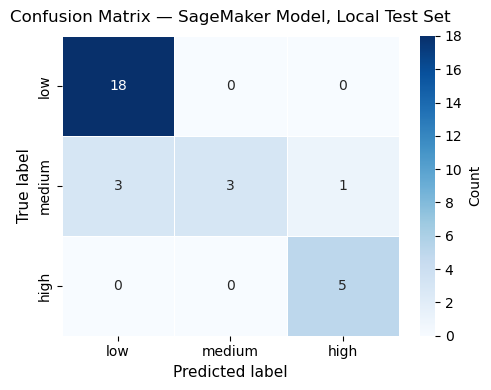

Per-class recall (fraction of each true class correctly identified):
  low     : 18/18 (100%)
  medium  : 3/7 (43%)
  high    : 5/5 (100%)


In [24]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
# Rows = true label, Cols = predicted label.
# Diagonal = correct predictions; off-diagonal = mistakes.
#
# For KYC the most dangerous error is:
#   high predicted as low (bottom-left corner) — a high-risk case slips through unreviewed.

from sklearn.metrics import confusion_matrix

cm_local = confusion_matrix(y_test_loc, y_pred_loc)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_local, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES_EVAL, yticklabels=LABEL_NAMES_EVAL, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Count'},
)
ax.set_ylabel('True label', fontsize=11)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_title('Confusion Matrix — SageMaker Model, Local Test Set', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print("Per-class recall (fraction of each true class correctly identified):")
for i, label in enumerate(LABEL_NAMES_EVAL):
    total   = int(cm_local[i].sum())
    correct = int(cm_local[i, i])
    pct     = correct / total * 100 if total else 0
    print(f"  {label:<8}: {correct}/{total} ({pct:.0f}%)")

In [25]:
# ── Build evaluation.json — same structure evaluate.py writes to S3 ───────────
# The SageMaker Pipeline's ConditionStep reads:
#     evaluation["metrics"]["auc_macro_ovr"]["value"]
# and compares it to AUC_THRESHOLD to decide register vs. fail.

eval_local = {
    "metrics": {
        "auc_macro_ovr": {"value": round(auc_local, 4), "standard_deviation": "NaN"},
        "accuracy"     : {"value": round(acc_local, 4), "standard_deviation": "NaN"},
    },
    "per_class": {
        label: {
            "precision": round(report_dict[label]["precision"], 4),
            "recall"   : round(report_dict[label]["recall"],    4),
            "f1"       : round(report_dict[label]["f1-score"],  4),
            "support"  : int(report_dict[label]["support"]),
        }
        for label in LABEL_NAMES_EVAL
        if label in report_dict
    },
    "confusion_matrix": {
        "labels": LABEL_NAMES_EVAL,
        "values": cm_local.tolist(),
    },
}

print("evaluation.json structure (written to S3 by evaluate.py):")
print(json.dumps(eval_local, indent=2))
print()
print("Pipeline decision logic (ConditionStep in pipeline.py):")
print(f"  auc_macro_ovr.value ({auc_local:.4f}) >= AUC_THRESHOLD ({AUC_THRESHOLD})")
print(f"  → {'RegisterModel ✓' if auc_local >= AUC_THRESHOLD else 'FailStep ✗'}")

evaluation.json structure (written to S3 by evaluate.py):
{
  "metrics": {
    "auc_macro_ovr": {
      "value": 0.8758,
      "standard_deviation": "NaN"
    },
    "accuracy": {
      "value": 0.8667,
      "standard_deviation": "NaN"
    }
  },
  "per_class": {
    "low": {
      "precision": 0.8571,
      "recall": 1.0,
      "f1": 0.9231,
      "support": 18
    },
    "medium": {
      "precision": 1.0,
      "recall": 0.4286,
      "f1": 0.6,
      "support": 7
    },
    "high": {
      "precision": 0.8333,
      "recall": 1.0,
      "f1": 0.9091,
      "support": 5
    }
  },
  "confusion_matrix": {
    "labels": [
      "low",
      "medium",
      "high"
    ],
    "values": [
      [
        18,
        0,
        0
      ],
      [
        3,
        3,
        1
      ],
      [
        0,
        0,
        5
      ]
    ]
  }
}

Pipeline decision logic (ConditionStep in pipeline.py):
  auc_macro_ovr.value (0.8758) >= AUC_THRESHOLD (0.85)
  → RegisterModel ✓


## 📊 Step 4: Evaluate on SageMaker

A second `SKLearnProcessor` job runs `scripts/evaluate.py`, which:

1. Extracts `model.tar.gz` and loads the XGBoost booster
2. Predicts class probabilities on the **test split** (never seen by the optimiser)
3. Computes macro-OVR AUC, accuracy, per-class precision/recall/F1
4. Writes `evaluation.json` to S3 (the pipeline's `ConditionStep` reads AUC from this file)

After the job completes we download `evaluation.json` and plot the confusion matrix and feature importance.

> `evaluate.py` installs `xgboost` at runtime inside the SKLearn container — that's why you see a
> `pip install` line in its logs.

In [12]:
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.processing import ProcessingInput, ProcessingOutput

eval_proc = SKLearnProcessor(
    framework_version='1.2-1',
    instance_type=INSTANCE_PROC,
    instance_count=1,
    role=ROLE,
    sagemaker_session=session,
    base_job_name='kyc-evaluate',
)

print('Submitting evaluation job …')
print(f'  Model artifact : {model_artifact_uri}')
print(f'  Test data      : {S3_PROCESSED}/test')
print(f'  Output         : {S3_EVALUATION}')
print()

eval_proc.run(
    code='scripts/evaluate.py',
    inputs=[
        # model.tar.gz is downloaded to the container as-is; evaluate.py extracts it
        ProcessingInput(
            source=model_artifact_uri,
            destination='/opt/ml/processing/input/model',
        ),
        # Held-out test split — the model has never seen these labels
        ProcessingInput(
            source=f'{S3_PROCESSED}/test',
            destination='/opt/ml/processing/input/test',
        ),
    ],
    outputs=[
        ProcessingOutput(
            output_name='evaluation',
            source='/opt/ml/processing/evaluation',
            destination=S3_EVALUATION,
        )
    ],
    wait=True,
    logs=True,
)

eval_job_name = eval_proc.latest_job.job_name
print(f'\n✓ Evaluation complete')
print(f'  Job name : {eval_job_name}')
print(f'  Report   : {S3_EVALUATION}/evaluation.json')

INFO:sagemaker.image_uris:Defaulting to only available Python version: py3


Submitting evaluation job …
  Model artifact : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-model/kyc-train-2026-07-08-22-14-34-520/output/model.tar.gz
  Test data      : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-processed/test
  Output         : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-evaluation



INFO:sagemaker:Creating processing-job with name kyc-evaluate-2026-07-08-22-26-24-037


.

.

...

.

.

.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
INFO:__main__:Model loaded from /tmp/model_extract
INFO:__main__:Test size: 30 rows
INFO:__main__:AUC (macro OVR): 0.8758
INFO:__main__:Accuracy:        0.8667
INFO:__main__:  low         precision=0.857  recall=1.000  f1=0.923  support=18
INFO:__main__:  medium      precision=1.000  recall=0.429  f1=0.600  support=7
INFO:__main__:  high        precision=0.833  recall=1.000  f1=0.909  support=5
INFO:__main__:Evaluation report → /opt/ml/processing/evaluation/evaluation.json



✓ Evaluation complete
  Job name : kyc-evaluate-2026-07-08-22-26-24-037
  Report   : s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-evaluation/evaluation.json


In [13]:
# ── Download evaluation.json and display metrics ───────────────────────────────

eval_s3_key = S3_EVALUATION.replace(f's3://{BUCKET}/', '') + '/evaluation.json'
obj         = s3_client.get_object(Bucket=BUCKET, Key=eval_s3_key)
evaluation  = json.loads(obj['Body'].read())

auc_val = evaluation['metrics']['auc_macro_ovr']['value']
acc_val = evaluation['metrics']['accuracy']['value']

print('=' * 55)
print('  KYC Risk Scorer — Evaluation Report (Test Set)')
print('=' * 55)
print(f'\n  AUC  (macro OVR) : {auc_val:.4f}')
print(f'  Accuracy         : {acc_val:.4f}')
print()

# ── Per-class table ────────────────────────────────────────────────────────────
print(f'  {"Class":<10}  {"Precision":>9}  {"Recall":>8}  {"F1":>6}  {"Support":>8}')
print('  ' + '-' * 50)
for cls, m in evaluation['per_class'].items():
    print(f'  {cls:<10}  {m["precision"]:>9.3f}  {m["recall"]:>8.3f}  '
          f'{m["f1"]:>6.3f}  {m["support"]:>8}')

# ── Full JSON for reference ────────────────────────────────────────────────────
print('\nFull evaluation.json:')
print(json.dumps(evaluation, indent=2))

  KYC Risk Scorer — Evaluation Report (Test Set)

  AUC  (macro OVR) : 0.8758
  Accuracy         : 0.8667

  Class       Precision    Recall      F1   Support
  --------------------------------------------------
  low             0.857     1.000   0.923        18
  medium          1.000     0.429   0.600         7
  high            0.833     1.000   0.909         5

Full evaluation.json:
{
  "metrics": {
    "auc_macro_ovr": {
      "value": 0.8758,
      "standard_deviation": "NaN"
    },
    "accuracy": {
      "value": 0.8667,
      "standard_deviation": "NaN"
    }
  },
  "per_class": {
    "low": {
      "precision": 0.8571,
      "recall": 1.0,
      "f1": 0.9231,
      "support": 18
    },
    "medium": {
      "precision": 1.0,
      "recall": 0.4286,
      "f1": 0.6,
      "support": 7
    },
    "high": {
      "precision": 0.8333,
      "recall": 1.0,
      "f1": 0.9091,
      "support": 5
    }
  },
  "confusion_matrix": {
    "labels": [
      "low",
      "medium",
      

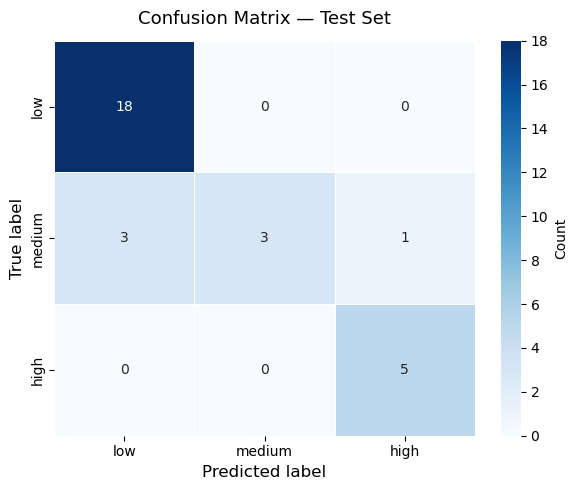

Per-class accuracy:
  low     : 18/18  (100.0%)
  medium  : 3/7  (42.9%)
  high    : 5/5  (100.0%)


In [14]:
# ── Confusion matrix heatmap ───────────────────────────────────────────────────
#
# Rows  = true labels (what the case actually was)
# Cols  = predicted labels (what the model said)
# The diagonal is correct predictions; off-diagonal = errors.

cm_values = np.array(evaluation['confusion_matrix']['values'])
cm_labels = evaluation['confusion_matrix']['labels']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_values,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Count'},
)
ax.set_ylabel('True label', fontsize=12)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# ── Per-class accuracy summary ────────────────────────────────────────────────
print('Per-class accuracy:')
for i, label in enumerate(cm_labels):
    total   = int(cm_values[i].sum())
    correct = int(cm_values[i, i])
    pct     = correct / total * 100 if total else 0
    print(f'  {label:<8}: {correct}/{total}  ({pct:.1f}%)')

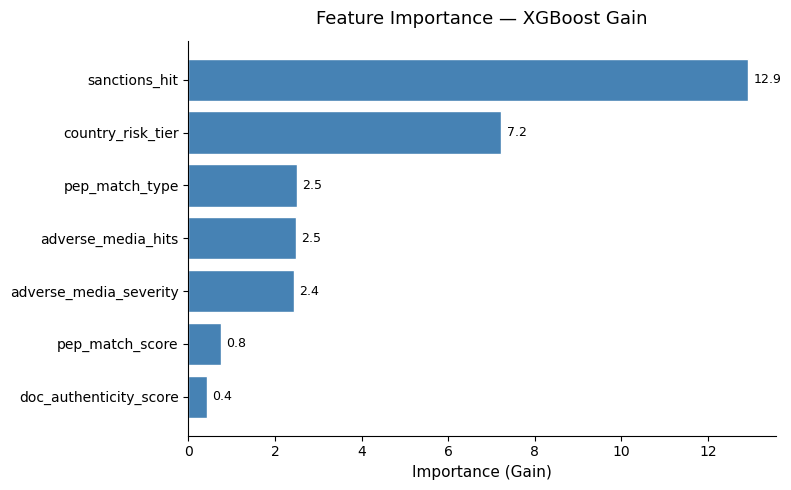

Feature importance ranking (gain):
  sanctions_hit                 ██████████████████████████████  12.9
  country_risk_tier             ████████████████                7.2
  pep_match_type                █████                           2.5
  adverse_media_hits            █████                           2.5
  adverse_media_severity        █████                           2.4
  pep_match_score               █                               0.8
  doc_authenticity_score                                        0.4


In [15]:
# ── Feature importance — load the booster we extracted in Step 3 ───────────────
#
# XGBoost names features f0, f1, … f7 internally (by position).
# We map them back to the real column names using FEATURE_NAMES.
#
# Importance type = 'gain' : total reduction in loss brought by splits on this feature.
# Higher gain → feature is more useful for the model's decisions.

booster = xgb.Booster()
booster.load_model(os.path.join(EXTRACT_DIR, 'xgboost-model'))

raw_importance = booster.get_score(importance_type='gain')

# Map f0..f7 → human-readable feature names
named_importance = {
    FEATURE_NAMES[int(k[1:])]: v
    for k, v in raw_importance.items()
}

# Sort descending by gain
sorted_feats = sorted(named_importance, key=named_importance.get, reverse=True)
sorted_vals  = [named_importance[f] for f in sorted_feats]
max_val      = max(sorted_vals)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sorted_feats[::-1], sorted_vals[::-1], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=4, fontsize=9)
ax.set_xlabel('Importance (Gain)', fontsize=11)
ax.set_title('Feature Importance — XGBoost Gain', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── ASCII bar chart for quick scanning ────────────────────────────────────────
print('Feature importance ranking (gain):')
for feat, val in zip(sorted_feats, sorted_vals):
    bar_len = int(val / max_val * 30)
    print(f'  {feat:<28}  {"█" * bar_len:<30}  {val:.1f}')

## ✅ Step 5: Quality Gate — AUC Check

The automated pipeline uses a `ConditionStep` with `AUC ≥ 0.85` as the gate.
Below we reproduce that check so you can see the decision logic before registering manually.

In [16]:
# ── Quality gate: does the model meet the AUC threshold? ─────────────────────

auc    = evaluation['metrics']['auc_macro_ovr']['value']
passes = auc >= AUC_THRESHOLD

GREEN, RED, RESET = '\033[92m', '\033[91m', '\033[0m'
colour = GREEN if passes else RED
symbol = '✓ PASS' if passes else '✗ FAIL'

print(f'AUC (macro OVR) : {auc:.4f}')
print(f'Threshold       : {AUC_THRESHOLD}')
print(f'Decision        : {colour}{symbol}{RESET}')

if passes:
    print('\nModel qualifies for registration — proceed to Step 6.')
else:
    print('\nAUC is below threshold. The pipeline FailStep would trigger.')
    print('Options: add more training data, tune hyperparameters, or lower AUC_THRESHOLD.')

AUC (macro OVR) : 0.8758
Threshold       : 0.85
Decision        : ✓ PASS

Model qualifies for registration — proceed to Step 6.


## 📦 Step 6: Register Model in SageMaker Model Registry

Registers the trained model as a new **version** in the `kyc-risk-scorer` package group.
Status is `PendingManualApproval` — a compliance officer must approve it in the
SageMaker console before it can be deployed.

The evaluation metrics are attached to the version so reviewers can inspect AUC directly
from the Model Registry UI without navigating to S3.

In [17]:
from sagemaker import image_uris
from sagemaker.model_metrics import MetricsSource, ModelMetrics

MODEL_PACKAGE_GROUP = 'kyc-risk-scorer'

# ── Ensure the package group exists ───────────────────────────────────────────
try:
    sm_client.describe_model_package_group(ModelPackageGroupName=MODEL_PACKAGE_GROUP)
    print(f'Model package group "{MODEL_PACKAGE_GROUP}" already exists.')
except sm_client.exceptions.ClientError:
    sm_client.create_model_package_group(
        ModelPackageGroupName=MODEL_PACKAGE_GROUP,
        ModelPackageGroupDescription='KYC risk scorer — XGBoost 3-class risk tier',
    )
    print(f'Created model package group "{MODEL_PACKAGE_GROUP}".')

# ── Retrieve the XGBoost inference container image for this region ─────────────
xgb_image = image_uris.retrieve(
    framework='xgboost',
    region=REGION,
    version='1.7-1',
    instance_type=INSTANCE_INFER,
    image_scope='inference',
)
print(f'\nXGBoost inference image : {xgb_image}')

# ── Register the model with evaluation metrics attached ───────────────────────
response = sm_client.create_model_package(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    ModelPackageDescription=(
        f'AUC={auc:.4f} | acc={acc_val:.4f} | '
        f'trained by {training_job_name}'
    ),
    InferenceSpecification={
        'Containers': [
            {
                'Image'        : xgb_image,
                'ModelDataUrl' : model_artifact_uri,
            }
        ],
        'SupportedContentTypes'              : ['text/csv'],
        'SupportedResponseMIMETypes'         : ['application/json'],
        'SupportedTransformInstanceTypes'    : ['ml.m5.large'],
        'SupportedRealtimeInferenceInstanceTypes': ['ml.m5.large', 'ml.m5.xlarge'],
    },
    ModelApprovalStatus='PendingManualApproval',
    ModelMetrics={
        'ModelQuality': {
            'Statistics': {
                'ContentType': 'application/json',
                'S3Uri': f'{S3_EVALUATION}/evaluation.json',
            }
         },
    }
)

pkg_arn = response['ModelPackageArn']
print(f'\n✓ Model registered')
print(f'  ARN    : {pkg_arn}')
print(f'  Status : PendingManualApproval')
print(f'\nApprove in: SageMaker Console → Models → Model Registry → {MODEL_PACKAGE_GROUP}')
print('Then run Step 7 to deploy.')

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: ml.m5.large.


Model package group "kyc-risk-scorer" already exists.

XGBoost inference image : 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1



✓ Model registered
  ARN    : arn:aws:sagemaker:us-east-1:926529379586:model-package/kyc-risk-scorer/2
  Status : PendingManualApproval

Approve in: SageMaker Console → Models → Model Registry → kyc-risk-scorer
Then run Step 7 to deploy.


In [37]:
import boto3
import tarfile

s3_uri = "s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-model/kyc-train-2026-07-08-20-55-37-857/output/model.tar.gz"

# Parse bucket/key
bucket = s3_uri.replace("s3://", "").split("/", 1)[0]
key = s3_uri.replace(f"s3://{bucket}/", "")

# Download
boto3.client("s3").download_file(
    bucket,
    key,
    "model.tar.gz"
)

# List contents
with tarfile.open("model.tar.gz", "r:gz") as tar:
    files = tar.getnames()
    print("Files in tarball:")
    for f in files:
        print(" ", f)

Files in tarball:
  xgboost-model
  model_meta.json


## 🚀 Step 7: Deploy to Real-Time Endpoint

Deploys the model to a persistent real-time endpoint with data capture enabled.

> **Cost reminder:** endpoints are billed per-hour. Delete it in Step 8 when done.

**Feature order the endpoint expects (comma-separated CSV string):**
```
pep_match_score, sanctions_hit, doc_authenticity_score,
adverse_media_hits, adverse_media_severity,
pep_match_type, doc_status, country_risk_tier
```
This matches `FEATURE_NAMES` above and what `risk_scoring_tool.py` sends.

**Response format:** comma-separated probabilities `P(low),P(medium),P(high)` — the class
with the highest probability is the predicted risk tier.

Deployment typically takes **5–8 minutes**.

In [26]:
from botocore.exceptions import ClientError

try:
    sm_client.delete_endpoint_config(
        EndpointConfigName="kyc-risk-scorer"
    )
    print("Endpoint config deleted")
except ClientError as e:
    if e.response["Error"]["Code"] == "ValidationException":
        print("Endpoint config does not exist")
    else:
        raise

Endpoint config deleted


In [22]:
from sagemaker.model import Model
from sagemaker.model_monitor import DataCaptureConfig
from sagemaker import image_uris

xgb_image = image_uris.retrieve(
    framework='xgboost',
    region=REGION,
    version='1.7-1',
    instance_type=INSTANCE_INFER,
    image_scope='inference',
)

model = Model(
    image_uri=xgb_image,
    model_data=model_artifact_uri,
    role=ROLE,
    sagemaker_session=session,
    name=f'kyc-risk-scorer-{int(time.time())}',
)

# Data capture records every request + response to S3 for later analysis
data_capture_cfg = DataCaptureConfig(
    enable_capture=True,
    sampling_percentage=100,
    destination_s3_uri=f's3://{BUCKET}/kyc-risk-capture/{ENDPOINT_NAME}',
    capture_options=['Input', 'Output'],
)

print(f'Deploying to endpoint "{ENDPOINT_NAME}" on {INSTANCE_INFER} …')
print('(This takes 5–8 minutes)')

predictor = model.deploy(
    initial_instance_count=1,
    instance_type=INSTANCE_INFER,
    endpoint_name=ENDPOINT_NAME,
    data_capture_config=data_capture_cfg,
    wait=True,
)

print(f'\n✓ Endpoint "{ENDPOINT_NAME}" is InService')
print(f'Set  RISK_SCORER_ENDPOINT_NAME={ENDPOINT_NAME}  in your Lambda environment.')

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: ml.m5.large.


INFO:sagemaker:Creating model with name: kyc-risk-scorer-1783550219


Deploying to endpoint "kyc-risk-scorer" on ml.m5.large …
(This takes 5–8 minutes)


INFO:sagemaker:Creating endpoint-config with name kyc-risk-scorer


INFO:sagemaker:Creating endpoint with name kyc-risk-scorer


...

-

-

-

!


✓ Endpoint "kyc-risk-scorer" is InService
Set  RISK_SCORER_ENDPOINT_NAME=kyc-risk-scorer  in your Lambda environment.


In [23]:
# ── Smoke test: invoke the endpoint with representative cases ──────────────────
#
# Payload format: pep_match_score, sanctions_hit, doc_authenticity_score,
#                 adverse_media_hits, adverse_media_severity,
#                 pep_match_type, doc_status, country_risk_tier

LABEL_MAP = {0: 'low', 1: 'medium', 2: 'high'}

smoke_cases = [
    ('Clean case  (expect: low)',   '0,0,95,0,0,0,2,1'),
    ('Fuzzy PEP   (expect: med)',  '35,0,65,2,1,1,1,3'),
    ('High risk   (expect: high)', '85,1,20,8,3,2,0,5'),
]

print('Smoke test results')
print('=' * 65)

for description, payload in smoke_cases:
    resp  = rt_client.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType='text/csv',
        Body=payload,
    )
    raw    = resp['Body'].read().decode().strip()
    probas = [float(x) for x in raw.split(',')]
    pred   = LABEL_MAP[int(np.argmax(probas))]

    print(f'\n  {description}')
    print(f'  Input     : {payload}')
    print(f'  P(low)    : {probas[0]:.4f}')
    print(f'  P(medium) : {probas[1]:.4f}')
    print(f'  P(high)   : {probas[2]:.4f}')
    print(f'  → Predicted risk tier : {pred.upper()}')

print()
print('=' * 65)
print('Endpoint is healthy. Data capture is writing to:')
print(f's3://{BUCKET}/kyc-risk-capture/{ENDPOINT_NAME}/')

Smoke test results



  Clean case  (expect: low)
  Input     : 0,0,95,0,0,0,2,1
  P(low)    : 0.4810
  P(medium) : 0.2825
  P(high)   : 0.2365
  → Predicted risk tier : LOW



  Fuzzy PEP   (expect: med)
  Input     : 35,0,65,2,1,1,1,3
  P(low)    : 0.2445
  P(medium) : 0.3407
  P(high)   : 0.4149
  → Predicted risk tier : HIGH

  High risk   (expect: high)
  Input     : 85,1,20,8,3,2,0,5
  P(low)    : 0.2366
  P(medium) : 0.3122
  P(high)   : 0.4512
  → Predicted risk tier : HIGH

Endpoint is healthy. Data capture is writing to:
s3://kyc-agent-mlops-926529379586-us-east-1/kyc-risk-capture/kyc-risk-scorer/


## 🧹 Step 8: Cleanup

Delete the real-time endpoint to stop per-hour charges.
All S3 artefacts (model, processed data, evaluation report, data capture) remain.

To delete everything: navigate to S3 and remove the `kyc-risk-*` prefixes under your bucket.

In [25]:
# Uncomment the line below and run this cell to delete the endpoint.
# predictor.delete_endpoint()
# print(f'Endpoint "{ENDPOINT_NAME}" deleted.')

# Or delete it directly via boto3:
sm_client.delete_endpoint(EndpointName=ENDPOINT_NAME)

print(f'When ready, delete endpoint "{ENDPOINT_NAME}" to stop charges.')
print('Uncomment predictor.delete_endpoint() above and re-run this cell.')

When ready, delete endpoint "kyc-risk-scorer" to stop charges.
Uncomment predictor.delete_endpoint() above and re-run this cell.
